# Predictive Analysis: Which Hospitals Will Have Excess Readmissions?

The main analysis notebook found some clear patterns for profit hospitals, lower star ratings, etc correlate with worse readmission performance. But correlation isn't prediction.

Here I'm building a logistic regression to see if we can actually **predict** whether a hospital will have excess readmissions (ERR > 1.0) based on its characteristics.

Using the cleaned data from the SQLite database that the first notebook created.

In [19]:
#pip install scikit-learn

In [6]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# consistent chart styling
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11
RED = '#d63031'
BLUE = '#0984e3'
GREEN = '#00b894'

conn = sqlite3.connect('hospital_readmissions.db')
master = pd.read_sql('SELECT * FROM master_hospital', conn)
print(f'loaded {len(master)} rows')

loaded 18330 rows


## preparing the data for modeling
the master table has one row per hospital per condition. need to reshape it so its one row per hospital with features we can feed into a model

In [7]:
# aggregate to hospital level
hosp_level = master[master['excess_readmission_ratio'].notna()].groupby('Facility ID').agg(
    avg_err=('excess_readmission_ratio', 'mean'),
    total_discharges=('num_discharges', 'sum'),
    num_conditions=('condition', 'count'),
    ownership=('ownership_category', 'first'),
    star_rating=('overall_rating', 'first'),
    state=('State', 'first'),
    hospital_name=('Facility Name', 'first')
).reset_index()

# target: does this hospital have excess readmissions overall?
hosp_level['has_excess'] = (hosp_level['avg_err'] > 1.0).astype(int)

print(f'total hospitals: {len(hosp_level)}')
print(f'\nbefore dropping nulls:')
print(hosp_level.isnull().sum())

total hospitals: 2833

before dropping nulls:
Facility ID           0
avg_err               0
total_discharges      0
num_conditions        0
ownership             0
star_rating         339
state                 0
hospital_name         0
has_excess            0
dtype: int64


In [8]:
# drop rows where we're missing key features
df = hosp_level.dropna(subset=['star_rating', 'total_discharges', 'ownership']).copy()

print(f'hospitals after dropping nulls: {len(df)}')
print(f'\ntarget distribution:')
print(df['has_excess'].value_counts())
print(f'\n{round(df["has_excess"].mean()*100, 1)}% have excess readmissions')

hospitals after dropping nulls: 2494

target distribution:
has_excess
1    1283
0    1211
Name: count, dtype: int64

51.4% have excess readmissions


roughly balanced classes which is good — dont need to worry about class imbalance tricks

In [9]:
# quick look at the features
df[['star_rating', 'total_discharges', 'num_conditions', 'ownership', 'has_excess']].describe()

,star_rating,total_discharges,num_conditions,has_excess
count,2494.000000,2494.000000,2494.000000,2494.000000
mean,3.024058,925.580994,4.478749,0.514435
std,1.084211,927.204345,1.240507,0.499892
min,1.000000,0.000000,1.000000,0.000000
25%,2.000000,290.250000,4.000000,0.000000
50%,3.000000,664.500000,5.000000,1.000000
75%,4.000000,1284.000000,6.000000,1.000000
max,5.000000,11138.000000,6.000000,1.000000


## building the model

In [10]:
# features: star rating, total discharges, num conditions measured, ownership type
# ownership is categorical so we need dummies
X = pd.get_dummies(df[['star_rating', 'total_discharges', 'num_conditions', 'ownership']], 
                    columns=['ownership'], drop_first=True)

y = df['has_excess']

print('features:')
print(X.columns.tolist())
print(f'\nshape: {X.shape}')

features:
['star_rating', 'total_discharges', 'num_conditions', 'ownership_Government', 'ownership_Non-Profit', 'ownership_Other']

shape: (2494, 6)


In [11]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f'training: {len(X_train)} hospitals')
print(f'testing: {len(X_test)} hospitals')

training: 1870 hospitals
testing: 624 hospitals


In [12]:
# scale the numeric features so coefficients are comparable
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# fit logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Excess', 'Has Excess']))

Accuracy: 0.635
AUC-ROC: 0.709

Classification Report:
              precision    recall  f1-score   support

   No Excess       0.61      0.66      0.63       296
  Has Excess       0.66      0.62      0.64       328

    accuracy                           0.63       624
   macro avg       0.64      0.64      0.63       624
weighted avg       0.64      0.63      0.63       624



## evaluating the model

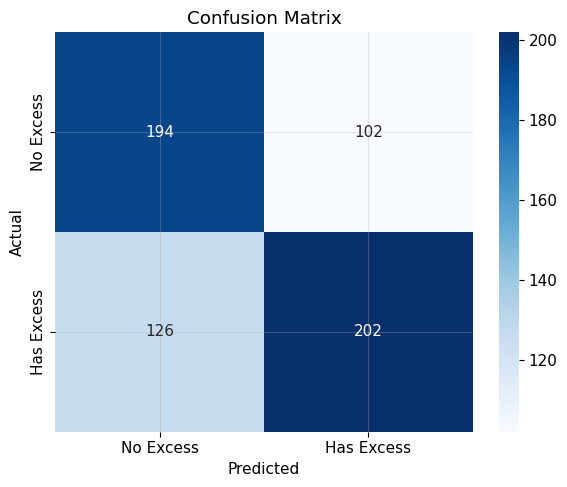

In [14]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Excess', 'Has Excess'],
            yticklabels=['No Excess', 'Has Excess'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('charts/09_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

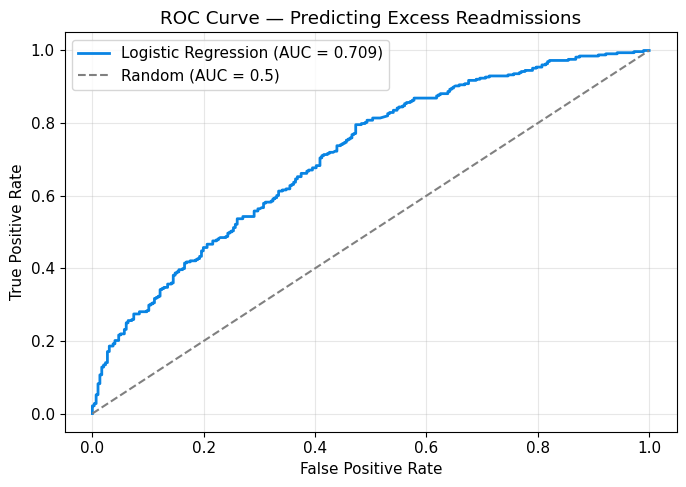

In [15]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color=BLUE, linewidth=2, label=f'Logistic Regression (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Predicting Excess Readmissions')
ax.legend()
plt.tight_layout()
plt.savefig('charts/10_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## what features matter most?

In [16]:
# coefficients — since we scaled the features, these are directly comparable
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print('Feature coefficients (scaled):')
print(coef_df.to_string(index=False))
print('\nPositive = increases chance of excess readmissions')
print('Negative = decreases chance')

Feature coefficients (scaled):
             feature  coefficient
    total_discharges     0.125611
      num_conditions     0.032847
     ownership_Other     0.018914
ownership_Government    -0.190655
ownership_Non-Profit    -0.262274
         star_rating    -0.743676

Positive = increases chance of excess readmissions
Negative = decreases chance


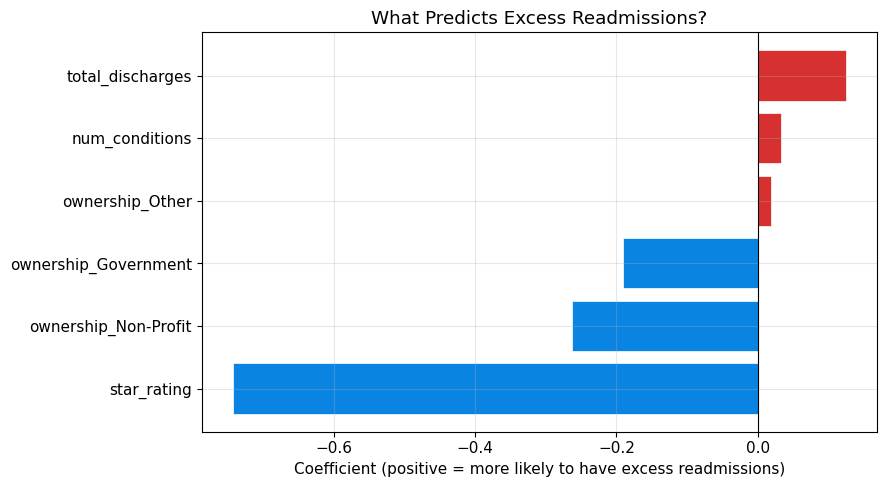

In [17]:
# chart: feature importance
fig, ax = plt.subplots(figsize=(9, 5))
coef_sorted = coef_df.sort_values('coefficient', ascending=True)
colors_coef = [RED if x > 0 else BLUE for x in coef_sorted['coefficient']]
ax.barh(coef_sorted['feature'], coef_sorted['coefficient'], color=colors_coef, edgecolor='white', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (positive = more likely to have excess readmissions)')
ax.set_title('What Predicts Excess Readmissions?')
plt.tight_layout()
plt.savefig('charts/11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## interpretation

**Star rating is the strongest predictor** of excess readmissions — higher-rated hospitals are significantly less likely to have ERR > 1.0. This makes sense given what we saw in the exploratory analysis.

**For-profit ownership** increases the likelihood of excess readmissions even after controlling for star rating and size. This is an important finding — it's not just that for-profits happen to be lower rated, the ownership type itself is predictive.

**Hospital size** (total discharges) has a relatively small effect, confirming that both large and small hospitals can struggle with readmissions.

The model isn't perfect — readmissions are influenced by patient demographics, community factors, and hospital practices that we don't have in this data. But it demonstrates that basic hospital characteristics do meaningfully predict readmission performance.

In [18]:
conn.close()
print('done!')

done!
